<a href="https://colab.research.google.com/github/edgyabin/testrepo/blob/main/Proyecto_EdgarYabinRamirezPatino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Dependencias

In [ ]:
import numpy as np
import pandas as pd
import pygal
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime,date
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from functools import reduce
from scipy.stats import ks_2samp
from varclushi import VarClusHi
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix,roc_auc_score,accuracy_score,plot_roc_curve
from sklearn.model_selection import validation_curve
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',200)

## Funciones

In [ ]:
#Definimos una funcion para las metricas
def metricas(model,Xv,yv): #Mide efectividad de un Modelo Predictivo
    print( " Roc Validate: %.3f" %roc_auc_score(y_score=model.predict_proba(Xv)[:,1],y_true=yv))
    print( " Acc Validate: %.3f" %accuracy_score(y_pred=model.predict(Xv),y_true=yv))
    print( " Matrix Conf Validate: ", "\n",confusion_matrix(y_pred=model.predict(Xv),y_true=yv))

In [ ]:
#Definimos una funcion para las frecuencias
def freq(df,var):
    if type(var)!=list:
        var = [var]
    for v in var:
        aux = df[v].value_counts().to_frame().rename(columns={v:'FA'})
        aux['FR'] = aux['FA']/aux['FA'].sum()
        aux[['FAA','FRA']] = aux.apply(np.cumsum)
        print("Tabla de frecuencias para la variable **",v,"**","\n"*2)
        print(aux,"\n"*2)

In [ ]:
#Definimos una funcion para normalizar
def normalizar(df,v,umbral=0.03):
    aux = df[v].value_counts(True).to_frame()
    aux[f'norm_{v}'] = np.where(aux[v]<umbral,'SMALL CATEGORIES',aux.index)
    moda = aux.head(1)[f'norm_{v}'].values[0]
    if aux.loc[aux[f'norm_{v}']=='SMALL CATEGORIES'][v].sum()<umbral:
        aux[f'norm_{v}'].replace({'SMALL CATEGORIES':moda},inplace=True)
    aux.drop(v,axis=1,inplace=True)
    aux.reset_index(inplace=True)
    return df.merge(aux,left_on=v,right_on='index',how='inner').drop('index',axis=1)

In [ ]:
def woe_generator(df,f,target):
    aux = df[[f,target]].copy()
    aux['n'] = 1

    aux = aux.pivot_table(columns=target,
                          index=f,
                          values='n',
                          aggfunc='count',
                          fill_value=0)

    aux['pne'] = aux[0]/aux[0].sum()
    aux['pe'] = aux[1]/aux[1].sum()

    aux['woe'] = np.log(aux['pne']/aux['pe'])

    aux['iv'] = aux['woe']*(aux['pne']-aux['pe'])
    return aux

In [ ]:
def iv(target,df,var):
    target =target
    iv_dict = {}
    for f in var:
        aux=woe_generator(df,f,target)

        iv_dict[f]=aux['iv'].sum()

    return iv_dict

## LECTURA DE DATOS

In [ ]:
#Leemos los datos del archivo csv
df = pd.read_csv('/home/edgyabin/Documents/Diplomado/ModuloV/Proyecto Final/insumo behavior score.csv')

In [ ]:
#Revisamos los primeros diez registros del dataframe
df.head(10)

,NCta,MAX_BK_12M,BK_T0_,V_1PV_0,V_2PV_0,V_3PV_0,V_4PV_0,V_5PV_0,V_6PV_0,SAL_0,SAL_1,SAL_2,SAL_3,SAL_4,SAL_5,max saldo,LC_T0,REV_0,REV_1,REV_2,REV_3,REV_4,REV_5,UTIL_0,UTIL_1,UTIL_2,UTIL_3,UTIL_4,UTIL_5,FLAG_CASH_T0,REGION_T0,MOB_T0,EDAD_T0,Flag_g_b
0,100001,0,0,0,0,0,0,0,0,760.15,0.00,0.00,119.82,147.78,180.47,760.15,900,0,0,0,2,77.835651,81.081209,84,0,0,13,16.420000,20.052222,0,2,13,20,0
1,100002,0,0,0,0,0,0,0,0,612.35,532.26,0.00,0.00,0.00,0.00,612.35,900,0,0,0,0,0.000000,0.000000,68,59,0,0,0.000000,0.000000,0,2,13,22,1
2,100003,0,0,1,0,0,0,0,0,198.03,298.03,105.03,255.03,397.04,0.00,397.04,1500,0,0,0,0,0.000000,0.000000,13,20,7,17,26.469333,0.000000,0,1,9,20,0
3,100004,1,1,3,0,0,0,0,0,817.87,816.64,573.71,279.41,125.96,233.46,817.87,1300,57,0,0,0,35.749165,65.595541,63,63,44,21,9.689231,17.958462,0,1,9,25,0
4,100005,0,0,0,0,0,0,0,0,1124.54,1239.67,862.67,832.68,849.96,968.39,1239.67,2700,0,0,0,0,79.347164,0.000000,42,46,32,31,31.480000,35.866296,0,1,9,38,0
5,100006,0,0,0,0,0,0,0,0,1152.85,1314.57,1362.54,894.02,977.92,915.33,1362.54,2400,63,71,63,50,77.275955,80.618675,48,55,57,37,40.746667,38.138750,0,1,9,50,0
6,100007,1,0,1,0,0,0,0,0,681.67,735.67,913.59,234.00,433.00,561.00,913.59,2700,0,29,100,0,43.493761,63.911290,25,27,34,9,16.037037,20.777778,0,1,9,34,0
7,100008,1,1,3,0,0,0,0,0,1579.15,1574.13,1450.11,497.19,713.18,1045.31,1579.15,1800,100,77,2,0,65.464790,66.933623,88,87,81,28,39.621111,58.072778,0,1,9,44,0
8,100009,0,0,0,0,0,0,0,0,661.74,946.41,885.08,1654.43,0.00,0.00,1654.43,4000,0,0,0,0,0.000000,0.000000,17,24,22,41,0.000000,0.000000,0,1,9,24,0
9,100010,0,0,0,0,0,0,0,0,1213.89,1508.78,1649.36,703.78,803.00,773.00,1649.36,1500,2,0,0,4,49.417853,66.408935,81,101,110,47,53.533333,51.533333,0,1,5,22,0


In [ ]:
#Revisamos el tamano
df.shape

(352777, 34)

## PRETRATAMIENTO

In [ ]:
#Revisamos el tipo de varibles
df.dtypes

NCta              int64
MAX_BK_12M        int64
BK_T0_            int64
V_1PV_0           int64
V_2PV_0           int64
V_3PV_0           int64
V_4PV_0           int64
V_5PV_0           int64
V_6PV_0           int64
SAL_0           float64
SAL_1           float64
SAL_2           float64
SAL_3           float64
SAL_4           float64
SAL_5           float64
max saldo       float64
LC_T0             int64
REV_0             int64
REV_1             int64
REV_2             int64
REV_3             int64
REV_4           float64
REV_5           float64
UTIL_0            int64
UTIL_1            int64
UTIL_2            int64
UTIL_3            int64
UTIL_4          float64
UTIL_5          float64
FLAG_CASH_T0      int64
REGION_T0         int64
MOB_T0            int64
EDAD_T0           int64
Flag_g_b          int64
dtype: object

In [ ]:
#Transformamos el tipo de variables
df['REV_4']=df['REV_4'].astype(int)
df['REV_5']=df['REV_5'].astype(int)
df['UTIL_4']=df['UTIL_4'].astype(int)
df['UTIL_5']=df['UTIL_5'].astype(int)

In [ ]:
#Revisamos la variable Flag_g_b
df['Flag_g_b'].value_counts(1)

0    0.813188
1    0.186812
Name: Flag_g_b, dtype: float64

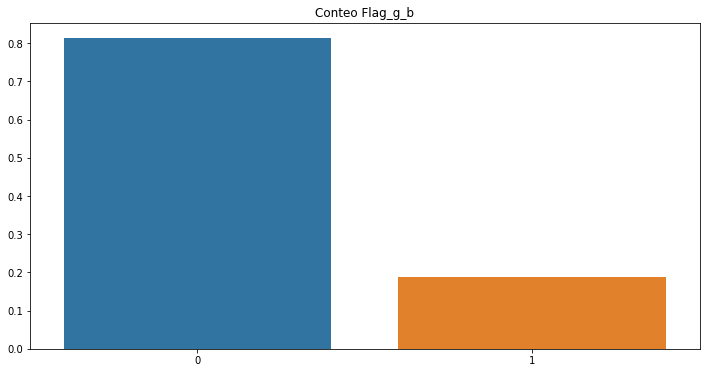

In [ ]:
#Graficamos su balanceo de clases
plt.figure(figsize=(12,6))
x=df['Flag_g_b'].value_counts(1).values
sns.barplot([0,1],x)
plt.title('Conteo Flag_g_b')
plt.show()

In [ ]:
#Revisamos la variable FLAG_CASH_T0
df['FLAG_CASH_T0'].value_counts(1)

0    0.992128
1    0.007872
Name: FLAG_CASH_T0, dtype: float64

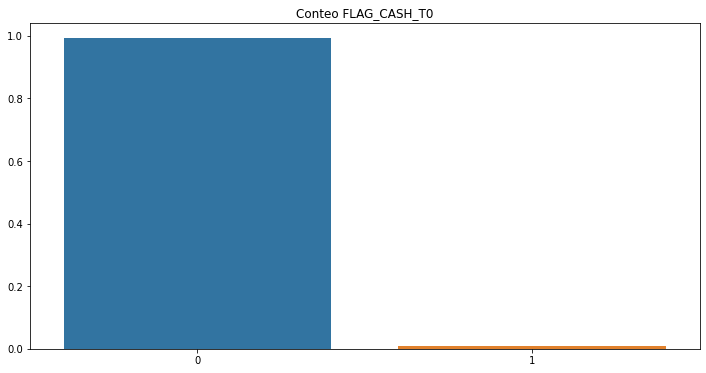

In [ ]:
#Graficamos FLAG_CASH_T0
plt.figure(figsize=(12,6))
x=df['FLAG_CASH_T0'].value_counts(1).values
sns.barplot([0,1],x)
plt.title('Conteo FLAG_CASH_T0')
plt.show()

In [ ]:
#Revisamos la variable REGION_T0
df['REGION_T0'].value_counts(1)

1    0.363142
2    0.199542
5    0.168869
3    0.163168
4    0.105279
Name: REGION_T0, dtype: float64

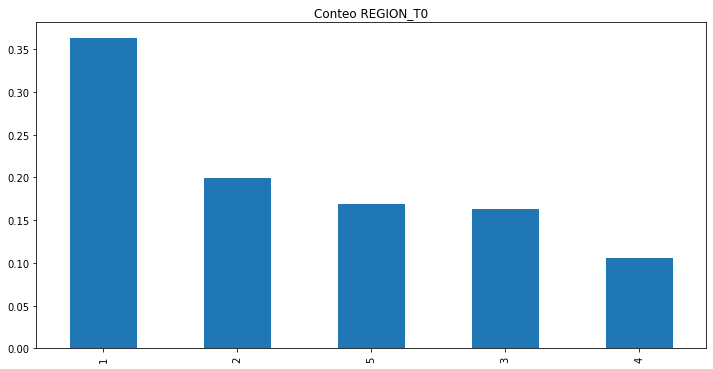

In [ ]:
#Graficamos la variable REGION_T0
plt.figure(figsize=(12,6))
x=df['REGION_T0'].value_counts(1).plot(kind = 'bar')
plt.title('Conteo REGION_T0')
plt.show()

In [ ]:
#Revisamos la variable MOB_T0
df['MOB_T0'].value_counts(1)

0     0.091624
10    0.063865
11    0.055746
7     0.048039
1     0.048010
2     0.047342
6     0.046698
12    0.045210
23    0.044155
4     0.043971
22    0.040584
3     0.038594
13    0.038220
5     0.037565
8     0.037154
14    0.036159
16    0.035181
9     0.034744
15    0.033616
19    0.031096
18    0.030473
17    0.025861
20    0.024704
21    0.021390
Name: MOB_T0, dtype: float64

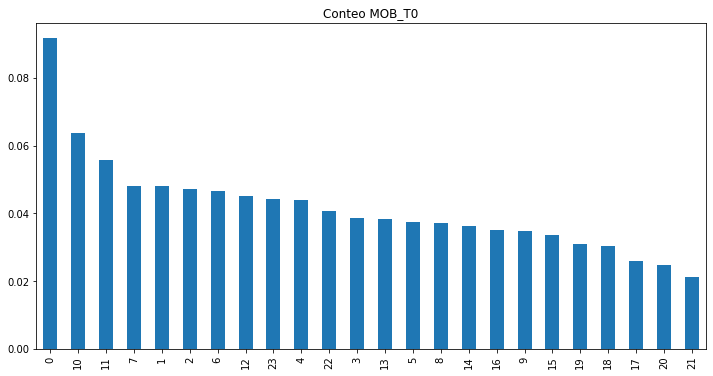

In [ ]:
#Graficamos la variable MOB_T0
plt.figure(figsize=(12,6))
x=df['MOB_T0'].value_counts(1).plot(kind = 'bar')
plt.title('Conteo MOB_T0')
plt.show()

In [ ]:
#Revisamos la variable EDAD_T0
df['EDAD_T0'].value_counts(1)

20     0.091120
21     0.075940
19     0.075059
22     0.065583
23     0.057427
         ...   
73     0.000003
83     0.000003
86     0.000003
88     0.000003
104    0.000003
Name: EDAD_T0, Length: 62, dtype: float64

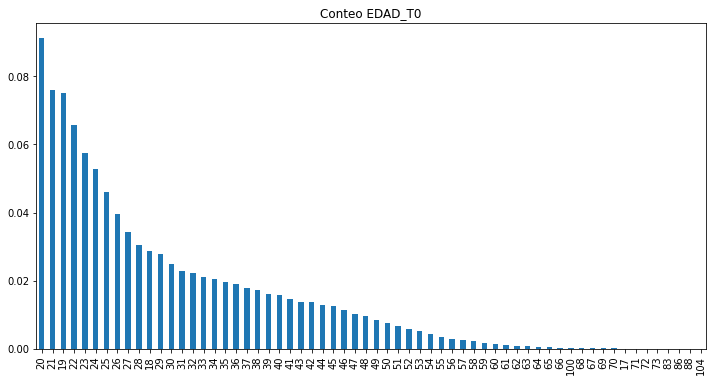

In [ ]:
#Graficamos la variable EDAD_T0
plt.figure(figsize=(12,6))
x=df['EDAD_T0'].value_counts(1).plot(kind = 'bar')
plt.title('Conteo EDAD_T0')
plt.show()

## SELECCION DE VARIABLES

In [ ]:
##Definimos nuestra variable objetivo, variables continuas, variables discretas y unidad muestral
tgt = 'Flag_g_b'
um = 'NCta'
var_d = [c for c in df.columns if int in (df[c].map(type).unique())]
fuera = ['Flag_g_b','NCta']
vard = [v for v in var_d if v not in fuera]
varc = [e for e in df.columns if float in (df[e].map(type).unique())]

In [ ]:
#Vemos cuales fueron las variables discretas
vard

['MAX_BK_12M',
 'BK_T0_',
 'V_1PV_0',
 'V_2PV_0',
 'V_3PV_0',
 'V_4PV_0',
 'V_5PV_0',
 'V_6PV_0',
 'LC_T0',
 'REV_0',
 'REV_1',
 'REV_2',
 'REV_3',
 'REV_4',
 'REV_5',
 'UTIL_0',
 'UTIL_1',
 'UTIL_2',
 'UTIL_3',
 'UTIL_4',
 'UTIL_5',
 'FLAG_CASH_T0',
 'REGION_T0',
 'MOB_T0',
 'EDAD_T0']

In [ ]:
#Vemos cuales fueron las variables continuas
varc

['SAL_0', 'SAL_1', 'SAL_2', 'SAL_3', 'SAL_4', 'SAL_5', 'max saldo']

## ANALISIS EXPLORATORIO DE DATOS

## DISCRETAS

### Frecuencia

In [ ]:
#Revisamos las frecuecias de las variables discretas
freq(df,vard)

Tabla de frecuencias para la variable ** MAX_BK_12M ** 


       FA        FR     FAA       FRA
0  210585  0.596935  210585  0.596935
1  115815  0.328295  326400  0.925230
2   21234  0.060191  347634  0.985421
3    3291  0.009329  350925  0.994750
4    1266  0.003589  352191  0.998339
5     395  0.001120  352586  0.999459
6     184  0.000522  352770  0.999980
7       4  0.000011  352774  0.999991
8       3  0.000009  352777  1.000000 


Tabla de frecuencias para la variable ** BK_T0_ ** 


       FA        FR     FAA       FRA
0  310873  0.881217  310873  0.881217
1   41904  0.118783  352777  1.000000 


Tabla de frecuencias para la variable ** V_1PV_0 ** 


          FA        FR     FAA       FRA
 0    205456  0.582396  205456  0.582396
 1     70851  0.200838  276307  0.783234
 2     33127  0.093904  309434  0.877138
 3     18747  0.053141  328181  0.930279
 4     11293  0.032012  339474  0.962291
 5      6289  0.017827  345763  0.980118
 6      3561  0.010094  349324  0.990212
 7   

### Ausentes

In [ ]:
#Revisamos los valores ausentes para las variables discretas
miss = 1-df[vard].describe().T[['count']]/len(df)
miss

,count
MAX_BK_12M,0.0
BK_T0_,0.0
V_1PV_0,0.0
V_2PV_0,0.0
V_3PV_0,0.0
V_4PV_0,0.0
V_5PV_0,0.0
V_6PV_0,0.0
LC_T0,0.0
REV_0,0.0


### Normalizacion

In [ ]:
#Normalizamos las variables discretas
for v in vard:
    df = normalizar(df,v)

In [ ]:
#Revisamos el dataframe con las varibles normalizadas
df.head(5)

,NCta,MAX_BK_12M,BK_T0_,V_1PV_0,V_2PV_0,V_3PV_0,V_4PV_0,V_5PV_0,V_6PV_0,SAL_0,SAL_1,SAL_2,SAL_3,SAL_4,SAL_5,max saldo,LC_T0,REV_0,REV_1,REV_2,REV_3,REV_4,REV_5,UTIL_0,UTIL_1,UTIL_2,UTIL_3,UTIL_4,UTIL_5,FLAG_CASH_T0,REGION_T0,MOB_T0,EDAD_T0,Flag_g_b,norm_MAX_BK_12M,norm_BK_T0_,norm_V_1PV_0,norm_V_2PV_0,norm_V_3PV_0,norm_V_4PV_0,norm_V_5PV_0,norm_V_6PV_0,norm_LC_T0,norm_REV_0,norm_REV_1,norm_REV_2,norm_REV_3,norm_REV_4,norm_REV_5,norm_UTIL_0,norm_UTIL_1,norm_UTIL_2,norm_UTIL_3,norm_UTIL_4,norm_UTIL_5,norm_FLAG_CASH_T0,norm_REGION_T0,norm_MOB_T0,norm_EDAD_T0
0,100001,0,0,0,0,0,0,0,0,760.15,0.00,0.00,119.82,147.78,180.47,760.15,900,0,0,0,2,77,81,84,0,0,13,16,20,0,2,13,20,0,0,0,0,0,0,0,0,0,SMALL CATEGORIES,0,0,0,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,0,0,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,0,2,13,20
1,357598,1,0,0,0,0,0,0,0,131.88,376.84,384.04,334.70,289.44,246.43,384.04,1200,68,100,100,0,100,100,11,31,32,28,24,20,0,2,13,20,0,1,0,0,0,0,0,0,0,1200,SMALL CATEGORIES,100,100,0,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,0,2,13,20
2,257385,0,0,1,1,0,0,0,0,215.10,382.71,569.95,656.95,184.58,247.63,656.95,1500,10,0,0,40,59,61,14,32,47,55,15,20,0,2,13,20,0,0,0,1,1,0,0,0,0,1500,SMALL CATEGORIES,0,0,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,0,2,13,20
3,185758,1,0,2,0,0,0,0,0,354.86,339.06,403.62,520.65,370.53,249.00,520.65,1200,63,100,70,69,60,60,30,28,34,43,30,20,0,2,13,20,0,1,0,2,0,0,0,0,0,1200,SMALL CATEGORIES,100,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,0,2,13,20
4,167825,1,1,1,0,0,0,0,0,1763.19,1465.63,1450.41,357.93,1162.84,254.50,1763.19,1250,100,74,100,26,56,35,141,117,116,29,93,20,0,2,13,20,0,1,1,1,0,0,0,0,0,1250,100,SMALL CATEGORIES,100,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,0,2,13,20


In [ ]:
#Depositamos los nombres de las columnas normalizadas en una lista
varn = df.filter(like='norm_').columns.tolist()

In [ ]:
#Los revisamos
varn

['norm_MAX_BK_12M',
 'norm_BK_T0_',
 'norm_V_1PV_0',
 'norm_V_2PV_0',
 'norm_V_3PV_0',
 'norm_V_4PV_0',
 'norm_V_5PV_0',
 'norm_V_6PV_0',
 'norm_LC_T0',
 'norm_REV_0',
 'norm_REV_1',
 'norm_REV_2',
 'norm_REV_3',
 'norm_REV_4',
 'norm_REV_5',
 'norm_UTIL_0',
 'norm_UTIL_1',
 'norm_UTIL_2',
 'norm_UTIL_3',
 'norm_UTIL_4',
 'norm_UTIL_5',
 'norm_FLAG_CASH_T0',
 'norm_REGION_T0',
 'norm_MOB_T0',
 'norm_EDAD_T0']

In [ ]:
#Revisamos su frecuencia
freq(df,varn)

Tabla de frecuencias para la variable ** norm_MAX_BK_12M ** 


       FA        FR     FAA       FRA
0  215728  0.611514  215728  0.611514
1  115815  0.328295  331543  0.939809
2   21234  0.060191  352777  1.000000 


Tabla de frecuencias para la variable ** norm_BK_T0_ ** 


       FA        FR     FAA       FRA
0  310873  0.881217  310873  0.881217
1   41904  0.118783  352777  1.000000 


Tabla de frecuencias para la variable ** norm_V_1PV_0 ** 


                      FA        FR     FAA       FRA
0                 205456  0.582396  205456  0.582396
1                  70851  0.200838  276307  0.783234
2                  33127  0.093904  309434  0.877138
3                  18747  0.053141  328181  0.930279
SMALL CATEGORIES   13303  0.037709  341484  0.967988
4                  11293  0.032012  352777  1.000000 


Tabla de frecuencias para la variable ** norm_V_2PV_0 ** 


       FA       FR     FAA      FRA
0  332891  0.94363  332891  0.94363
1   19886  0.05637  352777  1.00000 


T

In [ ]:
#Revisamos cuales de las normalizadas son unarias
unarias = [v for v,conteo in zip(varn,[df[v].unique().shape[0] for v in varn]) if conteo==1]
unarias

['norm_V_3PV_0',
 'norm_V_4PV_0',
 'norm_V_5PV_0',
 'norm_V_6PV_0',
 'norm_UTIL_0',
 'norm_FLAG_CASH_T0']

In [ ]:
#Quitamos las variables unarias de las normalizadas
varn = [v for v in varn if v not in unarias]
varn

['norm_MAX_BK_12M',
 'norm_BK_T0_',
 'norm_V_1PV_0',
 'norm_V_2PV_0',
 'norm_LC_T0',
 'norm_REV_0',
 'norm_REV_1',
 'norm_REV_2',
 'norm_REV_3',
 'norm_REV_4',
 'norm_REV_5',
 'norm_UTIL_1',
 'norm_UTIL_2',
 'norm_UTIL_3',
 'norm_UTIL_4',
 'norm_UTIL_5',
 'norm_REGION_T0',
 'norm_MOB_T0',
 'norm_EDAD_T0']

In [ ]:
#Revisamos su frecuencia
freq(df,varn)

Tabla de frecuencias para la variable ** norm_MAX_BK_12M ** 


       FA        FR     FAA       FRA
0  215728  0.611514  215728  0.611514
1  115815  0.328295  331543  0.939809
2   21234  0.060191  352777  1.000000 


Tabla de frecuencias para la variable ** norm_BK_T0_ ** 


       FA        FR     FAA       FRA
0  310873  0.881217  310873  0.881217
1   41904  0.118783  352777  1.000000 


Tabla de frecuencias para la variable ** norm_V_1PV_0 ** 


                      FA        FR     FAA       FRA
0                 205456  0.582396  205456  0.582396
1                  70851  0.200838  276307  0.783234
2                  33127  0.093904  309434  0.877138
3                  18747  0.053141  328181  0.930279
SMALL CATEGORIES   13303  0.037709  341484  0.967988
4                  11293  0.032012  352777  1.000000 


Tabla de frecuencias para la variable ** norm_V_2PV_0 ** 


       FA       FR     FAA      FRA
0  332891  0.94363  332891  0.94363
1   19886  0.05637  352777  1.00000 


T

## CONTINUAS

### ANALISIS UNIVARIADO

In [ ]:
#Describimos la informacion con los percentiles de las variables continuas
df[varc].describe(percentiles=[0.01,0.05,0.95,0.99])

,SAL_0,SAL_1,SAL_2,SAL_3,SAL_4,SAL_5,max saldo
count,352777.000000,352777.000000,352777.000000,352777.000000,352777.000000,352777.000000,352777.000000
mean,981.455183,879.263573,792.685085,700.438692,694.910226,655.543758,1289.326115
std,774.639371,780.952188,766.454428,870.306199,764.152692,765.293548,952.857290
min,100.010000,0.000000,0.000000,0.000000,0.000000,0.000000,100.010000
1%,110.367600,0.000000,0.000000,0.000000,0.000000,0.000000,130.930000
5%,158.910000,0.000000,0.000000,0.000000,0.000000,0.000000,244.298000
50%,809.860000,727.490000,642.460000,527.000000,528.000000,445.800000,1155.200000
95%,2418.604000,2312.282000,2212.356000,2081.472000,2114.882000,2096.408000,2810.080000
99%,3772.370800,3583.806800,3376.852800,3195.717600,3208.240000,3166.850800,4244.841600
max,35741.000000,34141.000000,9472.140000,114288.030000,8691.700000,12667.900000,114288.030000


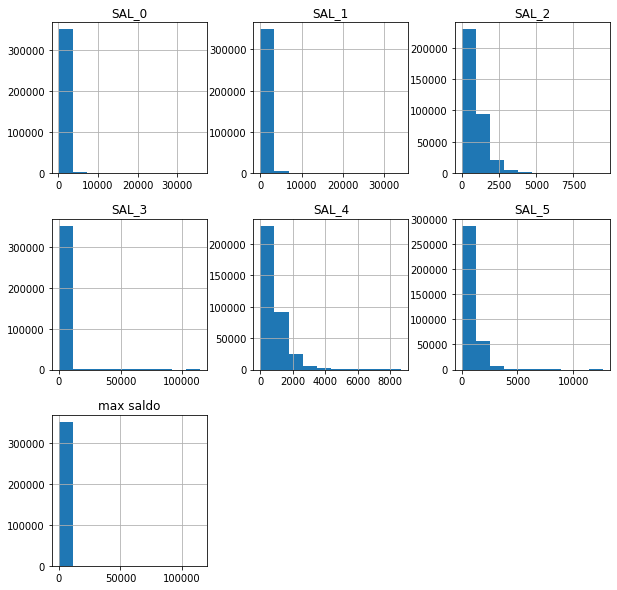

In [ ]:
#Graficamos su distribucion
df[varc].hist(figsize=(10,10))
plt.show()

###  Ausentes

In [ ]:
##Revisamos los valores ausentes para las variables continuas
miss = 1-df[varc].describe().T[['count']]/len(df)
miss

,count
SAL_0,0.0
SAL_1,0.0
SAL_2,0.0
SAL_3,0.0
SAL_4,0.0
SAL_5,0.0
max saldo,0.0


### Varianza

In [ ]:
#Utilizamos para revisar aquellas de poca varianza o nula
vt = VarianceThreshold(threshold=1)

In [ ]:
#Ajustamos a las variables continuas
vt.fit(df[varc])

VarianceThreshold(threshold=1)

In [ ]:
#Depositamos en una lista el nombre las columnas con poca varianza o nula
sin_varianza = [v for v,u in zip(varc,vt.get_support()) if not(u)]
sin_varianza

[]

### ANALISIS BIVARIADO

In [ ]:
#Revisamos la matriz de correlaciones
df[varc].corr()

,SAL_0,SAL_1,SAL_2,SAL_3,SAL_4,SAL_5,max saldo
SAL_0,1.000000,0.807961,0.676821,0.488196,0.485401,0.424497,0.774790
SAL_1,0.807961,1.000000,0.817353,0.575542,0.569962,0.499580,0.742486
SAL_2,0.676821,0.817353,1.000000,0.688296,0.675428,0.587161,0.704682
SAL_3,0.488196,0.575542,0.688296,1.000000,0.689896,0.596898,0.802583
SAL_4,0.485401,0.569962,0.675428,0.689896,1.000000,0.834354,0.611204
SAL_5,0.424497,0.499580,0.587161,0.596898,0.834354,1.000000,0.560870
max saldo,0.774790,0.742486,0.704682,0.802583,0.611204,0.560870,1.000000


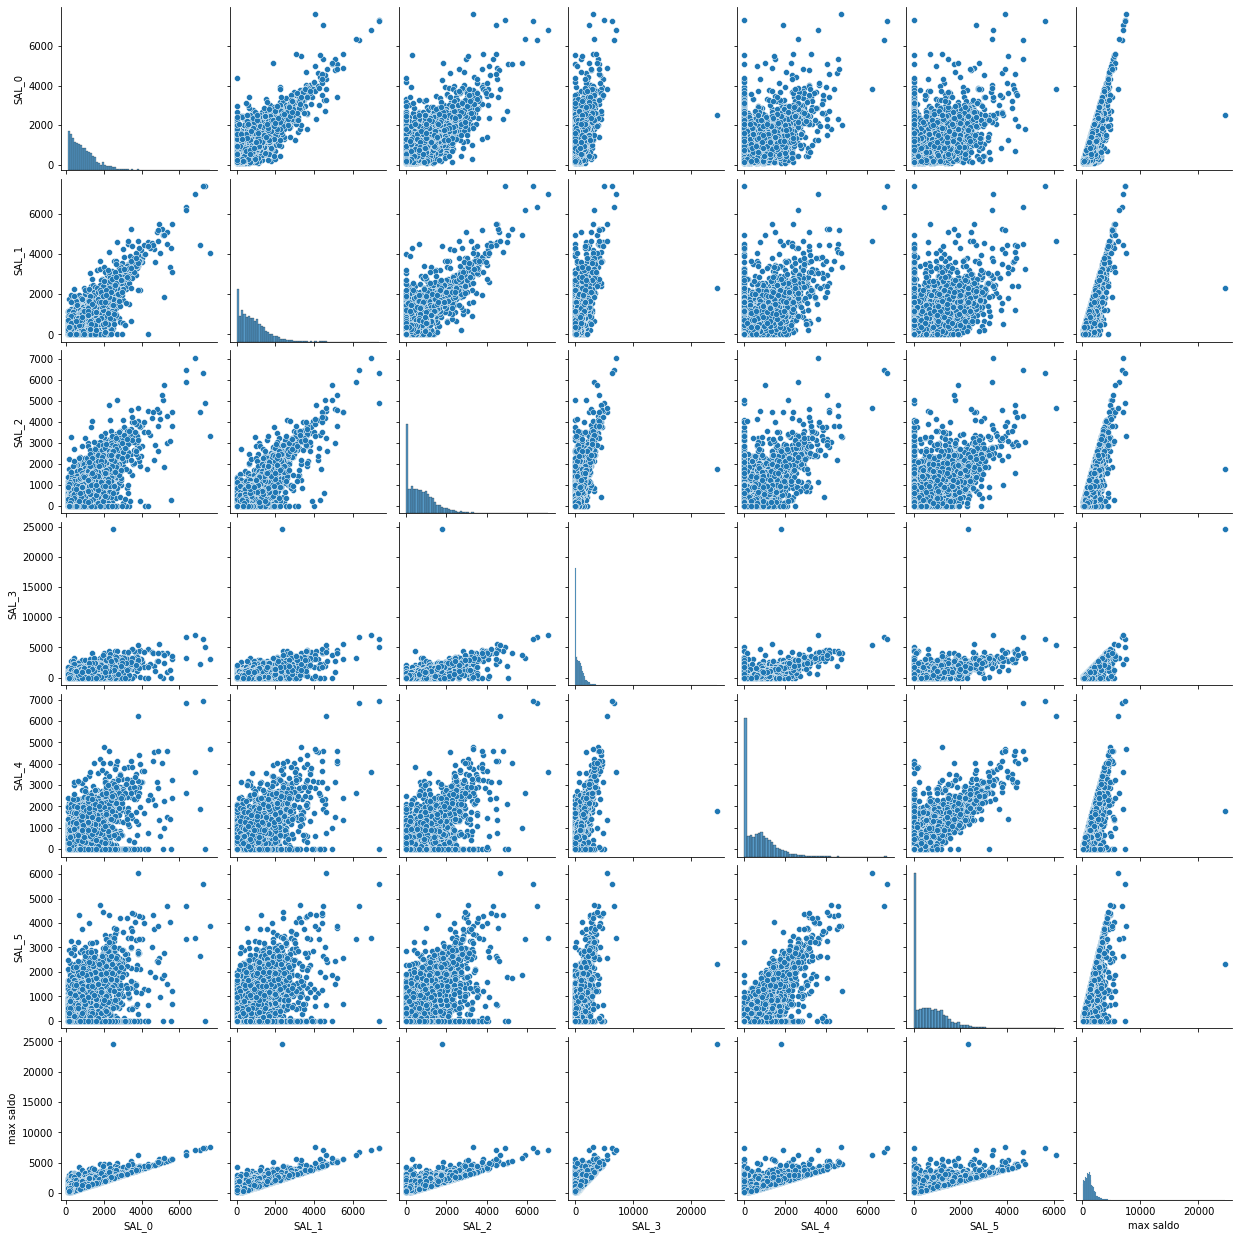

In [ ]:
#Graficamos las correlaciones
sns.pairplot(df[varc].sample(5000))
plt.show()

### Particionamiento

In [ ]:
#Realizamos las particiones a las variables continuas
for v in varc:
    df[f"C_{v}"] = pd.cut(df[v], bins=5).astype(str)

In [ ]:
df

,NCta,MAX_BK_12M,BK_T0_,V_1PV_0,V_2PV_0,V_3PV_0,V_4PV_0,V_5PV_0,V_6PV_0,SAL_0,SAL_1,SAL_2,SAL_3,SAL_4,SAL_5,max saldo,LC_T0,REV_0,REV_1,REV_2,REV_3,REV_4,REV_5,UTIL_0,UTIL_1,UTIL_2,UTIL_3,UTIL_4,UTIL_5,FLAG_CASH_T0,REGION_T0,MOB_T0,EDAD_T0,Flag_g_b,norm_MAX_BK_12M,norm_BK_T0_,norm_V_1PV_0,norm_V_2PV_0,norm_V_3PV_0,norm_V_4PV_0,norm_V_5PV_0,norm_V_6PV_0,norm_LC_T0,norm_REV_0,norm_REV_1,norm_REV_2,norm_REV_3,norm_REV_4,norm_REV_5,norm_UTIL_0,norm_UTIL_1,norm_UTIL_2,norm_UTIL_3,norm_UTIL_4,norm_UTIL_5,norm_FLAG_CASH_T0,norm_REGION_T0,norm_MOB_T0,norm_EDAD_T0,C_SAL_0,C_SAL_1,C_SAL_2,C_SAL_3,C_SAL_4,C_SAL_5,C_max saldo
0,100001,0,0,0,0,0,0,0,0,760.15,0.00,0.00,119.82,147.78,180.47,760.15,900,0,0,0,2,77,81,84,0,0,13,16,20,0,2,13,20,0,0,0,0,0,0,0,0,0,SMALL CATEGORIES,0,0,0,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,0,0,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,0,2,13,20,"(64.369, 7228.208]","(-34.141, 6828.2]","(-9.472, 1894.428]","(-114.288, 22857.606]","(-8.692, 1738.34]","(-12.668, 2533.58]","(-14.178, 22937.614]"
1,357598,1,0,0,0,0,0,0,0,131.88,376.84,384.04,334.70,289.44,246.43,384.04,1200,68,100,100,0,100,100,11,31,32,28,24,20,0,2,13,20,0,1,0,0,0,0,0,0,0,1200,SMALL CATEGORIES,100,100,0,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,0,2,13,20,"(64.369, 7228.208]","(-34.141, 6828.2]","(-9.472, 1894.428]","(-114.288, 22857.606]","(-8.692, 1738.34]","(-12.668, 2533.58]","(-14.178, 22937.614]"
2,257385,0,0,1,1,0,0,0,0,215.10,382.71,569.95,656.95,184.58,247.63,656.95,1500,10,0,0,40,59,61,14,32,47,55,15,20,0,2,13,20,0,0,0,1,1,0,0,0,0,1500,SMALL CATEGORIES,0,0,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,0,2,13,20,"(64.369, 7228.208]","(-34.141, 6828.2]","(-9.472, 1894.428]","(-114.288, 22857.606]","(-8.692, 1738.34]","(-12.668, 2533.58]","(-14.178, 22937.614]"
3,185758,1,0,2,0,0,0,0,0,354.86,339.06,403.62,520.65,370.53,249.00,520.65,1200,63,100,70,69,60,60,30,28,34,43,30,20,0,2,13,20,0,1,0,2,0,0,0,0,0,1200,SMALL CATEGORIES,100,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,0,2,13,20,"(64.369, 7228.208]","(-34.141, 6828.2]","(-9.472, 1894.428]","(-114.288, 22857.606]","(-8.692, 1738.34]","(-12.668, 2533.58]","(-14.178, 22937.614]"
4,167825,1,1,1,0,0,0,0,0,1763.19,1465.63,1450.41,357.93,1162.84,254.50,1763.19,1250,100,74,100,26,56,35,141,117,116,29,93,20,0,2,13,20,0,1,1,1,0,0,0,0,0,1250,100,SMALL CATEGORIES,100,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,0,2,13,20,"(64.369, 7228.208]","(-34.141, 6828.2]","(-9.472, 1894.428]","(-114.288, 22857.606]","(-8.692, 1738.34]","(-12.668, 2533.58]","(-14.178, 22937.614]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352772,446964,0,0,0,0,0,0,0,0,1081.55,0.00,0.00,0.00,0.00,0.00,1081.55,1000,0,0,0,0,0,0,108,0,0,0,0,0,0,3,0,17,0,0,0,0,0,0,0,0,0,1000,0,0,0,0,0,0,SMALL CATEGORIES,0,0,0,0,0,0,3,0,SMALL CATEGORIES,"(64.369, 7228.208]","(-34.141, 6828.2]","(-9.472, 1894.428]","(-114.288, 22857.606]","(-8.692, 1738.34]","(-12.668, 2533.58]","(-14.178, 22937.614]"
352773,451406,0,0,0,0,0,0,0,0,199.34,0.00,0.00,0.00,0.00,0.00,199.34,1000,0,0,0,0,0,0,20,0,0,0,0,0,0,4,0,17,1,0,0,0,0,0,0,0,0,1000,0,0,0,0,0,0,SMALL CATEGORIES,0,0,0,0,0,0,4,0,SMALL CATEGORIES,"(64.369, 7228.208]","(-34.141, 6828.2]","(-9.472, 1894.428]","(-114.288, 22857.606]","(-8.692, 1738.34]","(-12.668, 2533.58]","(-14.178, 22937.614]"
352774,449666,0,0,0,0,0,0,0,0,116

In [ ]:
#Las guardamos en una lista las particiones
vari = [x for x in df.columns if x.startswith("C_")]

In [ ]:
vari

['C_SAL_0',
 'C_SAL_1',
 'C_SAL_2',
 'C_SAL_3',
 'C_SAL_4',
 'C_SAL_5',
 'C_max saldo']

In [ ]:
#Juntamos las variables continuas y discretas en una solo
var = (vari+varn)[:]

In [ ]:
#Aplicamos el information value
iv(df = df, var = var, target= tgt)

{'C_SAL_0': inf,
 'C_SAL_1': inf,
 'C_SAL_2': 0.04417579317963307,
 'C_SAL_3': inf,
 'C_SAL_4': 0.028075556327061053,
 'C_SAL_5': inf,
 'C_max saldo': inf,
 'norm_MAX_BK_12M': 0.2878266593577071,
 'norm_BK_T0_': 0.2827789594328867,
 'norm_V_1PV_0': 0.22161224432514237,
 'norm_V_2PV_0': 0.0756830928671384,
 'norm_LC_T0': 0.021648640181070503,
 'norm_REV_0': 0.4318261944809315,
 'norm_REV_1': 0.2428418526430619,
 'norm_REV_2': 0.1546926804804491,
 'norm_REV_3': 0.0401663004092236,
 'norm_REV_4': 0.0005210035082214294,
 'norm_REV_5': 1.0828591450010863e-05,
 'norm_UTIL_1': 0.013222144346436043,
 'norm_UTIL_2': 0.008352630325964581,
 'norm_UTIL_3': 0.004348849592160019,
 'norm_UTIL_4': 0.00041171211446294786,
 'norm_UTIL_5': 0.00010078768680217951,
 'norm_REGION_T0': 0.027637963907690372,
 'norm_MOB_T0': 0.02204053917185572,
 'norm_EDAD_T0': 0.0018241524377326408}

In [ ]:
#Creamos un data frame con las variables
df_iv=pd.DataFrame(iv(df = df, var = var, target= tgt),index=[0]).T.reset_index().rename(columns={'index':'variable',0:'iv'})

In [ ]:
#Ordenamos los resultados de mayor iv a menor
df_iv.sort_values(by = "iv", ascending=False)

,variable,iv
0,C_SAL_0,inf
1,C_SAL_1,inf
3,C_SAL_3,inf
5,C_SAL_5,inf
6,C_max saldo,inf
12,norm_REV_0,0.431826
7,norm_MAX_BK_12M,0.287827
8,norm_BK_T0_,0.282779
13,norm_REV_1,0.242842
9,norm_V_1PV_0,0.221612


In [ ]:
#Elegimos quedarnos con las 9 primeras varibles con el iv mas alto y las ponemos en una lista
ls_best = list(df_iv[df_iv["iv"] != np.inf].sort_values(by = "iv", ascending=False).head(9)['variable'])

In [ ]:
ls_best

['norm_REV_0',
 'norm_MAX_BK_12M',
 'norm_BK_T0_',
 'norm_REV_1',
 'norm_V_1PV_0',
 'norm_REV_2',
 'norm_V_2PV_0',
 'C_SAL_2',
 'norm_REV_3']

In [ ]:
#Aplicamos el Weight of evidence
for feat in ls_best:
    woe_dict=woe_generator(df,feat,tgt)['woe'].to_dict()
    df[f'{feat}_woe']=df[feat].map(woe_dict)

In [ ]:
#Lo guardamos en una lista
ls_woe = [x for x in df.columns if x.endswith("woe")]

In [ ]:
ls_woe

['norm_REV_0_woe',
 'norm_MAX_BK_12M_woe',
 'norm_BK_T0__woe',
 'norm_REV_1_woe',
 'norm_V_1PV_0_woe',
 'norm_REV_2_woe',
 'norm_V_2PV_0_woe',
 'C_SAL_2_woe',
 'norm_REV_3_woe']

## MODELACION

In [ ]:
#Se hace la particion de entrenamiento del 70% y de validacion o test del 30%
X = df[ls_woe+[um]].copy()
y = df[[tgt]+[um]].copy()
Xt,Xv,yt,yv = train_test_split(X,y,train_size=0.7,random_state=2000)

In [ ]:
#Se define el nombre para la regresion
logistic = LogisticRegression()

In [ ]:
#Se ajusta la regresion
logistic.fit(Xt[ls_woe],yt[tgt])

LogisticRegression()

In [ ]:
#Vemos las metricas para el entrenamiento
metricas(logistic,Xt[ls_woe],yt[tgt])

 Roc Validate: 0.714
 Acc Validate: 0.817
 Matrix Conf Validate:  
 [[197925   3037]
 [ 42139   3842]]


In [ ]:
#Vemos las metricas para la validacion
metricas(logistic,Xv[ls_woe],yv[tgt])

 Roc Validate: 0.712
 Acc Validate: 0.814
 Matrix Conf Validate:  
 [[84591  1321]
 [18339  1583]]


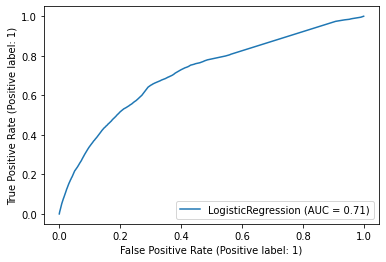

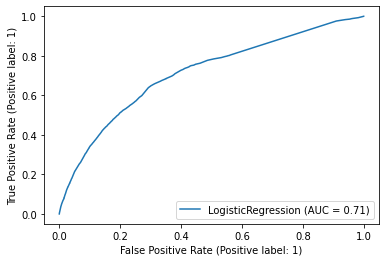

In [ ]:
#Graficamos las curvas ROC para entrenamiento y validacion
plot_roc_curve(logistic,Xt[ls_woe],yt[tgt])
plot_roc_curve(logistic,Xv[ls_woe],yv[tgt])

In [ ]:
#Se definen los numeros para el escalamiento de las betas
pdo = 50
base_score = 500
base_odds = 100
factor = pdo/np.log(2)
offset = base_score - (factor - np.log(base_odds))
m = len(ls_woe)

In [ ]:
#Se definen el alpha y betas
alpha = logistic.intercept_
betas = logistic.coef_[0]

In [ ]:
#Se realiza el escalamiento
for feat, beta in zip(ls_woe, betas):
    Xt["P_" + feat[:-4]] = Xt[feat].apply(lambda x:((-beta*x + (alpha/m))*factor) + (offset/m)).astype(int)
    Xv["P_" + feat[:-4]] = Xv[feat].apply(lambda x:((-beta*x + (alpha/m))*factor) + (offset/m)).astype(int)
    df["P_" + feat[:-4]] = df[feat].apply(lambda x:((-beta*x + (alpha/m))*factor) + (offset/m)).astype(int)

In [ ]:
#Se genera la variable Score en los conjuntos de entrenamiento, validacion y el dataframe total
Xt['score'] = Xt[[x for x in Xt.columns if x.startswith("P_")]].sum(axis = 1)
Xv['score'] = Xv[[x for x in Xv.columns if x.startswith("P_")]].sum(axis = 1)
df['score'] = df[[x for x in df.columns if x.startswith("P_")]].sum(axis = 1)

<AxesSubplot:xlabel='score', ylabel='Density'>

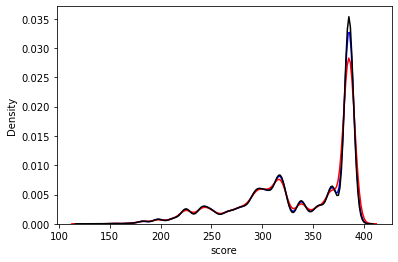

In [ ]:
#Se grafica el score
sns.distplot(Xt['score'],hist=False,color='b')
sns.distplot(Xv['score'],hist=False,color='r')
sns.distplot(df['score'],hist=False,color='k')

In [ ]:
#Describimos la informacion con los percentiles de la variable Score
df['score'].describe(percentiles=[0.01,0.05,0.95,0.99])

count    352777.000000
mean        334.658526
std          54.605990
min         129.000000
1%          196.000000
5%          226.000000
50%         351.000000
95%         386.000000
99%         390.000000
max         396.000000
Name: score, dtype: float64

### Crear scorecard

In [ ]:
#Guardamos en una lista las varialbes con puntaje
ls_var=[x for x in df.columns if x.startswith("P_")]

In [ ]:
#Hacemos nuestro Score Card
for var in ls_best:
    display(df[[var, "P_" + var]].groupby(var).last())

,P_norm_REV_0
norm_REV_0,
0,67
100,-4
SMALL CATEGORIES,19


,P_norm_MAX_BK_12M
norm_MAX_BK_12M,
0,46
1,26
2,11


,P_norm_BK_T0_
norm_BK_T0_,
0,45
1,-12


,P_norm_REV_1
norm_REV_1,
0,46
100,18
SMALL CATEGORIES,27


,P_norm_V_1PV_0
norm_V_1PV_0,
0,33
1,37
2,39
3,40
4,41
SMALL CATEGORIES,42


,P_norm_REV_2
norm_REV_2,
0,35
100,36
SMALL CATEGORIES,36


,P_norm_V_2PV_0
norm_V_2PV_0,
0,38
1,9


,P_C_SAL_2
C_SAL_2,
"(-9.472, 1894.428]",39
"(1894.428, 3788.856]",10
"(3788.856, 5683.284]",-5
"(5683.284, 7577.712]",-11
"(7577.712, 9472.14]",42


,P_norm_REV_3
norm_REV_3,
0,36
100,37
SMALL CATEGORIES,36


In [ ]:
#Revisamos el dataframe con todas las variables y el Score
df.head(10)

,NCta,MAX_BK_12M,BK_T0_,V_1PV_0,V_2PV_0,V_3PV_0,V_4PV_0,V_5PV_0,V_6PV_0,SAL_0,SAL_1,SAL_2,SAL_3,SAL_4,SAL_5,max saldo,LC_T0,REV_0,REV_1,REV_2,REV_3,REV_4,REV_5,UTIL_0,UTIL_1,UTIL_2,UTIL_3,UTIL_4,UTIL_5,FLAG_CASH_T0,REGION_T0,MOB_T0,EDAD_T0,Flag_g_b,norm_MAX_BK_12M,norm_BK_T0_,norm_V_1PV_0,norm_V_2PV_0,norm_V_3PV_0,norm_V_4PV_0,norm_V_5PV_0,norm_V_6PV_0,norm_LC_T0,norm_REV_0,norm_REV_1,norm_REV_2,norm_REV_3,norm_REV_4,norm_REV_5,norm_UTIL_0,norm_UTIL_1,norm_UTIL_2,norm_UTIL_3,norm_UTIL_4,norm_UTIL_5,norm_FLAG_CASH_T0,norm_REGION_T0,norm_MOB_T0,norm_EDAD_T0,C_SAL_0,C_SAL_1,C_SAL_2,C_SAL_3,C_SAL_4,C_SAL_5,C_max saldo,norm_REV_0_woe,norm_MAX_BK_12M_woe,norm_BK_T0__woe,norm_REV_1_woe,norm_V_1PV_0_woe,norm_REV_2_woe,norm_V_2PV_0_woe,C_SAL_2_woe,norm_REV_3_woe,P_norm_REV_0,P_norm_MAX_BK_12M,P_norm_BK_T0_,P_norm_REV_1,P_norm_V_1PV_0,P_norm_REV_2,P_norm_V_2PV_0,P_C_SAL_2,P_norm_REV_3,score
0,100001,0,0,0,0,0,0,0,0,760.15,0.00,0.00,119.82,147.78,180.47,760.15,900,0,0,0,2,77,81,84,0,0,13,16,20,0,2,13,20,0,0,0,0,0,0,0,0,0,SMALL CATEGORIES,0,0,0,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,0,0,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,0,2,13,20,"(64.369, 7228.208]","(-34.141, 6828.2]","(-9.472, 1894.428]","(-114.288, 22857.606]","(-8.692, 1738.34]","(-12.668, 2533.58]","(-14.178, 22937.614]",0.696502,0.476917,0.238607,0.447327,0.412029,0.340440,0.077720,0.068683,-0.242642,67,46,45,46,33,35,38,39,36,385
1,357598,1,0,0,0,0,0,0,0,131.88,376.84,384.04,334.70,289.44,246.43,384.04,1200,68,100,100,0,100,100,11,31,32,28,24,20,0,2,13,20,0,1,0,0,0,0,0,0,0,1200,SMALL CATEGORIES,100,100,0,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,0,2,13,20,"(64.369, 7228.208]","(-34.141, 6828.2]","(-9.472, 1894.428]","(-114.288, 22857.606]","(-8.692, 1738.34]","(-12.668, 2533.58]","(-14.178, 22937.614]",-0.381018,-0.429826,0.238607,-0.779032,0.412029,-0.690457,0.077720,0.068683,0.090214,19,26,45,18,33,36,38,39,36,290
2,257385,0,0,1,1,0,0,0,0,215.10,382.71,569.95,656.95,184.58,247.63,656.95,1500,10,0,0,40,59,61,14,32,47,55,15,20,0,2,13,20,0,0,0,1,1,0,0,0,0,1500,SMALL CATEGORIES,0,0,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,0,2,13,20,"(64.369, 7228.208]","(-34.141, 6828.2]","(-9.472, 1894.428]","(-114.288, 22857.606]","(-8.692, 1738.34]","(-12.668, 2533.58]","(-14.178, 22937.614]",-0.381018,0.476917,0.238607,0.447327,-0.154953,0.340440,-0.979885,0.068683,-0.242642,19,46,45,46,37,35,9,39,36,312
3,185758,1,0,2,0,0,0,0,0,354.86,339.06,403.62,520.65,370.53,249.00,520.65,1200,63,100,70,69,60,60,30,28,34,43,30,20,0,2,13,20,0,1,0,2,0,0,0,0,0,1200,SMALL CATEGORIES,100,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,0,2,13,20,"(64.369, 7228.208]","(-34.141, 6828.2]","(-9.472, 1894.428]","(-114.288, 22857.606]","(-8.692, 1738.34]","(-12.668, 2533.58]","(-14.178, 22937.614]",-0.381018,-0.429826,0.238607,-0.779032,-0.485057,-0.214026,0.077720,0.068683,-0.242642,19,26,45,18,39,36,38,39,36,296
4,167825,1,1,1,0,0,0,0,0,1763.19,1465.63,1450.41,357.93,1162.84,254.50,1763.19,1250,100,74,100,26,56,35,141,117,116,29,93,20,0,2,13,20,0,1,1,1,0,0,0,0,0,1250,100,SMALL CATEGORIES,100,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,SMALL CATEGORIES,0,2,13,20,"(64.369, 7228.208]","(-34.141, 6828.2]","(-9.472, 1894.428]","(-114.288, 22857.606]","(-8.692, 1738.34]","(-12.668, 2533.58]","(-14.178, 22937.614]",-0.908757,-0.429826,-1.213142,-0.380233,-0.154953,-0.690457,0.077720,0.068683,-0.242642,-4,26,-12,27,37,36,38,39,36,223
5,387571,0,0,0,0,0,0,0,0,386.76,199.54,240.27,237.85,1129.04,244.27,1129.04,1800,0,0,81,0,77,71,21,17,20,20,94,20,0,2,13,20,0,0,0,0,0,0,

## GUARDAR EL MODELO Y DESCARGAR EN CSV

In [ ]:
df.to_pickle('proyecto_edgaryabinramirezpatino.pkl')

In [ ]:
df.to_csv('proyecto_edgaryabinramirezpatino.csv',index=False)